# Task 1: Deep Learning


## Team Members and Contributions

| Member | Name | Student ID | Contribution | Individual Contribution Factor |
|---|---|---|---|---|
| 1 | Waralee Sidokmai | 105089004 | Dataset preprocessing and final review | 1.0 |
| 2 | Name 2 | TBC | Deep Learning model | 1.0 |
| 3 | Name 3 | TBC | Deep Learning evaluation and DL vs ML comparison | 1.0 |
| 4 | Name 4 | TBC | Machine Learning feature extraction | 1.0 |
| 5 | Name 5 | TBC | Machine Learning model and hyperparameter tuning | 1.0 |
| 6 | Name 6 | TBC | Machine Learning evaluation and appendix support | 1.0 |


## 1. Dataset Loading and Preprocessing

This section loads and preprocesses the CIFAR-10 dataset by checking the official train/test split, displaying sample images, normalizing image data, preparing labels, and handing the prepared variables to the next sections.

The same CIFAR-10 train/test split should also be used in the ML notebook so the final DL vs ML comparison is fair.


### 1.1 Import Libraries and Set Up


In [ ]:
from pathlib import Path
import pickle
import tarfile
import urllib.request

import matplotlib.pyplot as plt
import numpy as np

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
DATA_DIR = Path("data")
ARCHIVE_PATH = DATA_DIR / "cifar-10-python.tar.gz"
EXTRACTED_DIR = DATA_DIR / "cifar-10-batches-py"

### 1.2 Download and Extract CIFAR-10


In [ ]:
def download_cifar10():
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    if EXTRACTED_DIR.exists():
        print("CIFAR-10 already extracted")
        return

    if not ARCHIVE_PATH.exists():
        print("Downloading CIFAR-10...")
        urllib.request.urlretrieve(DATA_URL, ARCHIVE_PATH)
        print("Download complete")

    print("Extracting CIFAR-10...")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(DATA_DIR)

    print("Extraction complete")

download_cifar10()

Download complete
Extracting CIFAR-10...


/tmp/ipykernel_411/418038931.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


Extraction complete


### 1.3 Load CIFAR-10 Data


In [ ]:
def unpickle(file_path):
    with open(file_path, "rb") as file:
        data = pickle.load(file, encoding="latin1")
    return data

def load_cifar10():
    train_images = []
    train_labels = []

    for batch_number in range(1, 6):
        batch_path = EXTRACTED_DIR / f"data_batch_{batch_number}"
        batch = unpickle(batch_path)

        images = batch["data"]
        labels = batch["labels"]

        # CIFAR-10 stores each image as a flat array. Reshape it to 32 x 32 RGB format.
        images = images.reshape(-1, 3, 32, 32)
        images = images.transpose(0, 2, 3, 1)

        train_images.append(images)
        train_labels.append(labels)

    test_batch = unpickle(EXTRACTED_DIR / "test_batch")

    x_train = np.concatenate(train_images)
    y_train = np.concatenate(train_labels)

    x_test = test_batch["data"]
    y_test = np.array(test_batch["labels"])

    x_test = x_test.reshape(-1, 3, 32, 32)
    x_test = x_test.transpose(0, 2, 3, 1)

    meta = unpickle(EXTRACTED_DIR / "batches.meta")
    class_names = meta["label_names"]

    return x_train, y_train, x_test, y_test, class_names

x_train, y_train, x_test, y_test, class_names = load_cifar10()

print("CIFAR-10 data loaded")

CIFAR-10 data loaded


### 1.4 Check Dataset Information


In [ ]:
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

print("\nNumber of classes:", len(class_names))
print("Class names:", class_names)

print("\nClass distribution:")
for class_id, class_name in enumerate(class_names):
    train_count = np.sum(y_train == class_id)
    test_count = np.sum(y_test == class_id)
    print(f"{class_name}: train={train_count}, test={test_count}")

Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000,)
Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000,)

Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Class distribution:
airplane: train=5000, test=1000
automobile: train=5000, test=1000
bird: train=5000, test=1000
cat: train=5000, test=1000
deer: train=5000, test=1000
dog: train=5000, test=1000
frog: train=5000, test=1000
horse: train=5000, test=1000
ship: train=5000, test=1000
truck: train=5000, test=1000


### 1.5 Display Sample Images


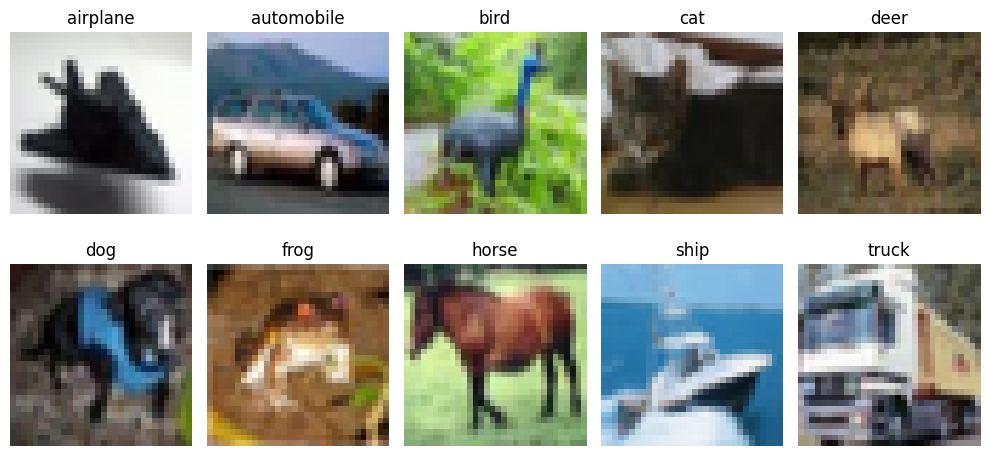

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    # Display one training image from each CIFAR-10 class.
    class_index = np.where(y_train == i)[0][0]

    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[class_index], interpolation="nearest")
    plt.title(class_names[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

CIFAR-10 images are low resolution because each image is only 32 x 32 pixels.


### 1.6 Normalize Data


In [ ]:
# Normalize pixel values from 0-255 to 0-1 for neural network training.
x_train_normalized = x_train.astype("float32") / 255.0
x_test_normalized = x_test.astype("float32") / 255.0

print("Training data min:", x_train_normalized.min())
print("Training data max:", x_train_normalized.max())
print("Testing data min:", x_test_normalized.min())
print("Testing data max:", x_test_normalized.max())

Training data min: 0.0
Training data max: 1.0
Testing data min: 0.0
Testing data max: 1.0


The image pixel values were normalized from 0-255 to 0-1 so the model receives input values on a smaller and consistent scale.


### 1.7 Prepare Labels


In [ ]:
# Keep labels as integer class IDs for sparse categorical loss or CrossEntropyLoss.
y_train_labels = y_train.copy()
y_test_labels = y_test.copy()

print("Training labels shape:", y_train_labels.shape)
print("Testing labels shape:", y_test_labels.shape)
print("Example labels:", y_train_labels[:10])

Training labels shape: (50000,)
Testing labels shape: (10000,)
Example labels: [6 9 9 4 1 1 2 7 8 3]


### 1.8 Final Preprocessing Check


In [ ]:
print("Final training data shape:", x_train_normalized.shape)
print("Final testing data shape:", x_test_normalized.shape)
print("Final training labels shape:", y_train_labels.shape)
print("Final testing labels shape:", y_test_labels.shape)

print("\nData type:", x_train_normalized.dtype)
print("Number of classes:", len(class_names))

assert x_train_normalized.shape == (50000, 32, 32, 3)
assert x_test_normalized.shape == (10000, 32, 32, 3)
assert y_train_labels.shape == (50000,)
assert y_test_labels.shape == (10000,)
assert x_train_normalized.min() >= 0 and x_train_normalized.max() <= 1
assert x_test_normalized.min() >= 0 and x_test_normalized.max() <= 1
assert len(class_names) == 10

print("Preprocessing check passed")

Final training data shape: (50000, 32, 32, 3)
Final testing data shape: (10000, 32, 32, 3)
Final training labels shape: (50000,)
Final testing labels shape: (10000,)

Data type: float32
Number of classes: 10
Preprocessing check passed


### 1.9 Prepared Data for Deep Learning Model


In [ ]:
x_train_dl = x_train_normalized
x_test_dl = x_test_normalized
y_train_dl = y_train_labels
y_test_dl = y_test_labels

print("x_train_dl:", x_train_dl.shape)
print("x_test_dl:", x_test_dl.shape)
print("y_train_dl:", y_train_dl.shape)
print("y_test_dl:", y_test_dl.shape)

x_train_dl: (50000, 32, 32, 3)
x_test_dl: (10000, 32, 32, 3)
y_train_dl: (50000,)
y_test_dl: (10000,)


## 2. Deep Learning Model


### 2.1 Framework and Candidate Models

This section develops three candidate deep learning models for CIFAR-10 image classification. The models are chosen to compare increasing levels of complexity: a simple CNN baseline, a regularised CNN, and a transfer learning CNN.

| Model | Type | Reason for inclusion |
|---|---|---|
| Baseline CNN | Custom CNN trained from scratch | Provides a simple reference model using convolution, ReLU, max pooling, and dense layers |
| Improved CNN | Deeper custom CNN trained from scratch | Adds batch normalization, dropout, and global pooling to improve generalisation |
| VGG16 | Pre-trained CNN adapted for CIFAR-10 | Tests whether reusable visual features from ImageNet improve validation performance |

The purpose of training three candidates is to justify the final architecture selection using evidence rather than choosing one model directly. The best model is selected using validation accuracy only, while the official CIFAR-10 test set is kept for final evaluation.


In [ ]:
# Import deep learning and evaluation tools
import time
import random
import pickle
from pathlib import Path

import numpy as np

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader, random_split
    import torchvision.models as models
    import torchvision.transforms as T
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "This section requires PyTorch and torchvision. The easiest option is to run "
        "development_DL.ipynb in Google Colab with GPU enabled. For local Jupyter, "
        "install them in the notebook kernel with: %pip install torch torchvision"
    ) from error

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Fix random seeds for reproducible train/validation splitting and training.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Use GPU in Colab when available; otherwise fall back to CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


### 2.2 Data Pipeline and Validation Split

The official CIFAR-10 training set is split into 45,000 training images and 5,000 validation images using a fixed random seed. The validation set is used for model selection, while the 10,000 official test images are reserved for final performance evaluation.

Two transform pipelines are used:

| Pipeline | Used by | Reason |
|---|---|---|
| 32x32 CIFAR-10 pipeline | Baseline CNN and Improved CNN | Keeps the original CIFAR-10 resolution for models trained from scratch |
| 224x224 ImageNet pipeline | VGG16 | Matches the input size and normalization expected by the pre-trained VGG16 backbone |


In [ ]:
# Compute CIFAR-10 normalization statistics from the training data only.
pixels = x_train_dl.reshape(-1, 3)
CIFAR10_MEAN = tuple(pixels.mean(axis=0).round(4))
CIFAR10_STD = tuple(pixels.std(axis=0).round(4))

# ImageNet normalization is used only for the pre-trained VGG16 model.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

print("CIFAR-10 mean:", CIFAR10_MEAN)
print("CIFAR-10 std:", CIFAR10_STD)


class CIFAR10ArrayDataset(Dataset):
    """Wrap pre-loaded CIFAR-10 numpy arrays for PyTorch training."""

    def __init__(self, images, labels, transform=None):
        self.images = (images * 255).astype(np.uint8)
        self.labels = labels.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        image = self.images[index]
        label = int(self.labels[index])
        if self.transform is not None:
            image = self.transform(image)
        return image, label


class TransformSubset(Dataset):
    """Apply different transforms to train and validation subsets."""

    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        image, label = self.subset[index]
        image = self.transform(image)
        return image, label


# Split the official training set into train and validation sets.
full_train_dataset = CIFAR10ArrayDataset(x_train_dl, y_train_dl, transform=None)
generator = torch.Generator().manual_seed(RANDOM_SEED)
train_subset, val_subset = random_split(
    full_train_dataset,
    [45_000, 5_000],
    generator=generator,
)

# Transforms for CNN models trained from scratch.
train_transform_cnn = T.Compose([
    T.ToPILImage(),
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

val_transform_cnn = T.Compose([
    T.ToPILImage(),
    T.ToTensor(),
    T.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

# Transforms for VGG16 transfer learning.
train_transform_vgg = T.Compose([
    T.ToPILImage(),
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(p=0.5),
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform_vgg = T.Compose([
    T.ToPILImage(),
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Create datasets and dataloaders.
BATCH_SIZE = 64
NUM_WORKERS = 0
PIN_MEMORY = DEVICE.type == "cuda"

train_dataset_cnn = TransformSubset(train_subset, train_transform_cnn)
val_dataset_cnn = TransformSubset(val_subset, val_transform_cnn)
train_dataset_vgg = TransformSubset(train_subset, train_transform_vgg)
val_dataset_vgg = TransformSubset(val_subset, val_transform_vgg)

test_dataset_cnn = CIFAR10ArrayDataset(x_test_dl, y_test_dl, transform=val_transform_cnn)
test_dataset_vgg = CIFAR10ArrayDataset(x_test_dl, y_test_dl, transform=val_transform_vgg)

train_loader_cnn = DataLoader(train_dataset_cnn, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader_cnn = DataLoader(val_dataset_cnn, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
train_loader_vgg = DataLoader(train_dataset_vgg, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader_vgg = DataLoader(val_dataset_vgg, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

test_loader_cnn = DataLoader(test_dataset_cnn, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader_vgg = DataLoader(test_dataset_vgg, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

# These loaders are prepared for final evaluation only. They are not used for model selection.
dl_test_loaders = {
    "BaselineCNN": test_loader_cnn,
    "ImprovedCNN": test_loader_cnn,
    "VGG16": test_loader_vgg,
}

dl_validation_loaders = {
    "BaselineCNN": val_loader_cnn,
    "ImprovedCNN": val_loader_cnn,
    "VGG16": val_loader_vgg,
}

print("Training images:", len(train_dataset_cnn))
print("Validation images:", len(val_dataset_cnn))
print("Testing images reserved for final evaluation:", len(test_dataset_cnn))


CIFAR-10 mean: (np.float32(0.3277), np.float32(0.3277), np.float32(0.3277))
CIFAR-10 std: (np.float32(0.2776), np.float32(0.2693), np.float32(0.2681))
Training images: 45000
Validation images: 5000
Testing images reserved for final evaluation: 10000


### 2.3 Training Utilities

The same training function is used for all three candidate models so the comparison is fair and reproducible. Each model is trained on the training split, monitored on the validation split, and selected using validation accuracy. Early stopping is included to reduce overfitting and unnecessary training time.


In [ ]:
# Training settings
NUM_CLASSES = 10
EPOCHS_CNN = 10
EPOCHS_VGG = 5
LR_CNN = 1e-3
LR_VGG = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 3

criterion = nn.CrossEntropyLoss()
results = {}


def count_params(model):
    """Return the number of model parameters in millions."""
    return sum(param.numel() for param in model.parameters()) / 1e6


def run_epoch(model, loader, optimizer=None):
    """Run one training or validation epoch."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


def train_model(model, model_name, train_loader, val_loader, epochs, learning_rate, save_path):
    """Train a model and keep the checkpoint with the best validation accuracy."""
    model = model.to(DEVICE)
    optimizer = optim.Adam(
        filter(lambda param: param.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY,
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = -1.0
    best_epoch = 0
    epochs_without_improvement = 0
    start_time = time.time()

    print()
    print(f"Training {model_name}")
    print("-" * 60)

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, optimizer=optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, optimizer=None)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            epochs_without_improvement = 0
            torch.save({
                "model_name": model_name,
                "model_state": model.state_dict(),
                "best_val_acc": best_val_acc,
                "best_epoch": best_epoch,
                "history": history,
            }, save_path)
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

        if epochs_without_improvement >= PATIENCE:
            print("Early stopping triggered")
            break

    checkpoint = torch.load(save_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state"])
    training_time = time.time() - start_time

    return model, history, best_val_acc, best_epoch, training_time


### 2.4 Model 1 - Baseline CNN

The baseline model uses core CNN operations for image classification: convolution, ReLU activation, max pooling, flattening, and fully connected layers. It provides a simple comparison point for the deeper models.


In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


baseline_cnn = BaselineCNN(num_classes=NUM_CLASSES)
print(f"Baseline CNN parameters: {count_params(baseline_cnn):.2f}M")

baseline_model, baseline_history, baseline_best_acc, baseline_best_epoch, baseline_time = train_model(
    baseline_cnn,
    "BaselineCNN",
    train_loader_cnn,
    val_loader_cnn,
    epochs=EPOCHS_CNN,
    learning_rate=LR_CNN,
    save_path="best_baseline_cnn.pth",
)

results["BaselineCNN"] = {
    "model": baseline_model,
    "history": baseline_history,
    "best_val_acc": baseline_best_acc,
    "best_epoch": baseline_best_epoch,
    "params_M": count_params(baseline_model),
    "train_sec": baseline_time,
    "checkpoint": "best_baseline_cnn.pth",
}


Baseline CNN parameters: 0.55M

Training BaselineCNN
------------------------------------------------------------
Epoch 01/10 | train_loss=1.6573, train_acc=0.3916 | val_loss=1.3354, val_acc=0.5148
Epoch 02/10 | train_loss=1.3664, train_acc=0.5054 | val_loss=1.1218, val_acc=0.5988
Epoch 03/10 | train_loss=1.2379, train_acc=0.5558 | val_loss=1.0320, val_acc=0.6346
Epoch 04/10 | train_loss=1.1634, train_acc=0.5839 | val_loss=0.9818, val_acc=0.6488
Epoch 05/10 | train_loss=1.1089, train_acc=0.6035 | val_loss=0.9499, val_acc=0.6590
Epoch 06/10 | train_loss=1.0740, train_acc=0.6202 | val_loss=0.8780, val_acc=0.6886
Epoch 07/10 | train_loss=1.0346, train_acc=0.6348 | val_loss=0.9047, val_acc=0.6714
Epoch 08/10 | train_loss=1.0143, train_acc=0.6422 | val_loss=0.8387, val_acc=0.7040
Epoch 09/10 | train_loss=0.9861, train_acc=0.6521 | val_loss=0.8053, val_acc=0.7146
Epoch 10/10 | train_loss=0.9703, train_acc=0.6587 | val_loss=0.8972, val_acc=0.6824


### 2.5 Model 2 - Improved CNN

The improved CNN extends the baseline architecture by adding batch normalization and dropout. Batch normalization stabilizes training, while dropout reduces overfitting.


In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.block(x)


class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


improved_cnn = ImprovedCNN(num_classes=NUM_CLASSES)
print(f"Improved CNN parameters: {count_params(improved_cnn):.2f}M")

improved_model, improved_history, improved_best_acc, improved_best_epoch, improved_time = train_model(
    improved_cnn,
    "ImprovedCNN",
    train_loader_cnn,
    val_loader_cnn,
    epochs=EPOCHS_CNN,
    learning_rate=LR_CNN,
    save_path="best_improved_cnn.pth",
)

results["ImprovedCNN"] = {
    "model": improved_model,
    "history": improved_history,
    "best_val_acc": improved_best_acc,
    "best_epoch": improved_best_epoch,
    "params_M": count_params(improved_model),
    "train_sec": improved_time,
    "checkpoint": "best_improved_cnn.pth",
}


Improved CNN parameters: 0.29M

Training ImprovedCNN
------------------------------------------------------------
Epoch 01/10 | train_loss=1.4033, train_acc=0.4872 | val_loss=1.1125, val_acc=0.6016
Epoch 02/10 | train_loss=1.0139, train_acc=0.6426 | val_loss=0.9235, val_acc=0.6698
Epoch 03/10 | train_loss=0.8608, train_acc=0.7004 | val_loss=0.7763, val_acc=0.7198
Epoch 04/10 | train_loss=0.7617, train_acc=0.7363 | val_loss=0.7022, val_acc=0.7530
Epoch 05/10 | train_loss=0.6923, train_acc=0.7647 | val_loss=0.7037, val_acc=0.7580
Epoch 06/10 | train_loss=0.6510, train_acc=0.7794 | val_loss=0.6686, val_acc=0.7698
Epoch 07/10 | train_loss=0.6046, train_acc=0.7944 | val_loss=0.6825, val_acc=0.7714
Epoch 08/10 | train_loss=0.5710, train_acc=0.8072 | val_loss=0.6918, val_acc=0.7656
Epoch 09/10 | train_loss=0.5498, train_acc=0.8154 | val_loss=0.5874, val_acc=0.7964
Epoch 10/10 | train_loss=0.5227, train_acc=0.8232 | val_loss=0.6527, val_acc=0.7868


### 2.6 Model 3 - VGG16 Transfer Learning

VGG16 is used as the third candidate because it is a well-established convolutional neural network for image classification. The pre-trained weights come from ImageNet through `torchvision`, not from CIFAR-10. All pre-trained layers are frozen and only the final classifier layer is replaced and trained for the 10 CIFAR-10 classes.


In [ ]:
# Pre-trained weights: ImageNet-1K through torchvision, not CIFAR-10.
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Freeze all pre-trained VGG16 layers.
for param in vgg16.parameters():
    param.requires_grad = False

# Replace the final classifier layer so only this new layer trains on CIFAR-10.
vgg16.classifier[6] = nn.Linear(in_features=4096, out_features=NUM_CLASSES)
print(f"VGG16 parameters: {count_params(vgg16):.2f}M")
print(
    "VGG16 trainable parameters: "
    f"{sum(param.numel() for param in vgg16.parameters() if param.requires_grad) / 1e6:.2f}M"
)

vgg16_model, vgg16_history, vgg16_best_acc, vgg16_best_epoch, vgg16_time = train_model(
    vgg16,
    "VGG16",
    train_loader_vgg,
    val_loader_vgg,
    epochs=EPOCHS_VGG,
    learning_rate=LR_VGG,
    save_path="best_vgg16.pth",
)

results["VGG16"] = {
    "model": vgg16_model,
    "history": vgg16_history,
    "best_val_acc": vgg16_best_acc,
    "best_epoch": vgg16_best_epoch,
    "params_M": count_params(vgg16_model),
    "train_sec": vgg16_time,
    "checkpoint": "best_vgg16.pth",
}


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 92.9MB/s]


VGG16 parameters: 134.30M
VGG16 trainable parameters: 0.04M

Training VGG16
------------------------------------------------------------
Epoch 01/5 | train_loss=0.9858, train_acc=0.6881 | val_loss=0.6484, val_acc=0.7784
Epoch 02/5 | train_loss=0.6848, train_acc=0.7654 | val_loss=0.5857, val_acc=0.7930
Epoch 03/5 | train_loss=0.6432, train_acc=0.7739 | val_loss=0.5575, val_acc=0.8002
Epoch 04/5 | train_loss=0.6248, train_acc=0.7824 | val_loss=0.5352, val_acc=0.8102
Epoch 05/5 | train_loss=0.6103, train_acc=0.7863 | val_loss=0.5227, val_acc=0.8142


### 2.7 Model Selection

The table below compares the three candidate models using validation accuracy, training time, and parameter count. Validation accuracy is used for model selection because the test set must remain unseen until final evaluation.


In [ ]:
print(f"{'Model':<14} {'Best Val Acc':>14} {'Best Epoch':>12} {'Params (M)':>12} {'Train Time (min)':>18}")
print("-" * 76)

for name, result in results.items():
    print(
        f"{name:<14} "
        f"{result['best_val_acc']:>14.4f} "
        f"{result['best_epoch']:>12} "
        f"{result['params_M']:>12.2f} "
        f"{result['train_sec'] / 60:>18.1f}"
    )

best_dl_model_name = max(results, key=lambda name: results[name]["best_val_acc"])
best_dl_model = results[best_dl_model_name]["model"]
best_dl_checkpoint_path = results[best_dl_model_name]["checkpoint"]
best_dl_test_loader = dl_test_loaders[best_dl_model_name]

print()
print("Selected best DL model:", best_dl_model_name)
print("Best validation accuracy:", round(results[best_dl_model_name]["best_val_acc"], 4))
print("Checkpoint for final evaluation:", best_dl_checkpoint_path)


Model            Best Val Acc   Best Epoch   Params (M)   Train Time (min)
----------------------------------------------------------------------------
BaselineCNN            0.7146            9         0.55                3.6
ImprovedCNN            0.7964            9         0.29                4.4
VGG16                  0.8142            5       134.30               31.2

Selected best DL model: VGG16
Best validation accuracy: 0.8142
Checkpoint for final evaluation: best_vgg16.pth


### 2.8 Training and Validation Results

The validation results show that VGG16 achieved the highest validation accuracy at 81.42%, followed by the Improved CNN at 79.64% and the Baseline CNN at 71.46%. Therefore, VGG16 is selected as the final deep learning model for later test-set evaluation.

The plots below compare training loss, validation loss, and validation accuracy for the three candidate models. These curves help show whether the models are learning consistently and whether there are signs of overfitting.


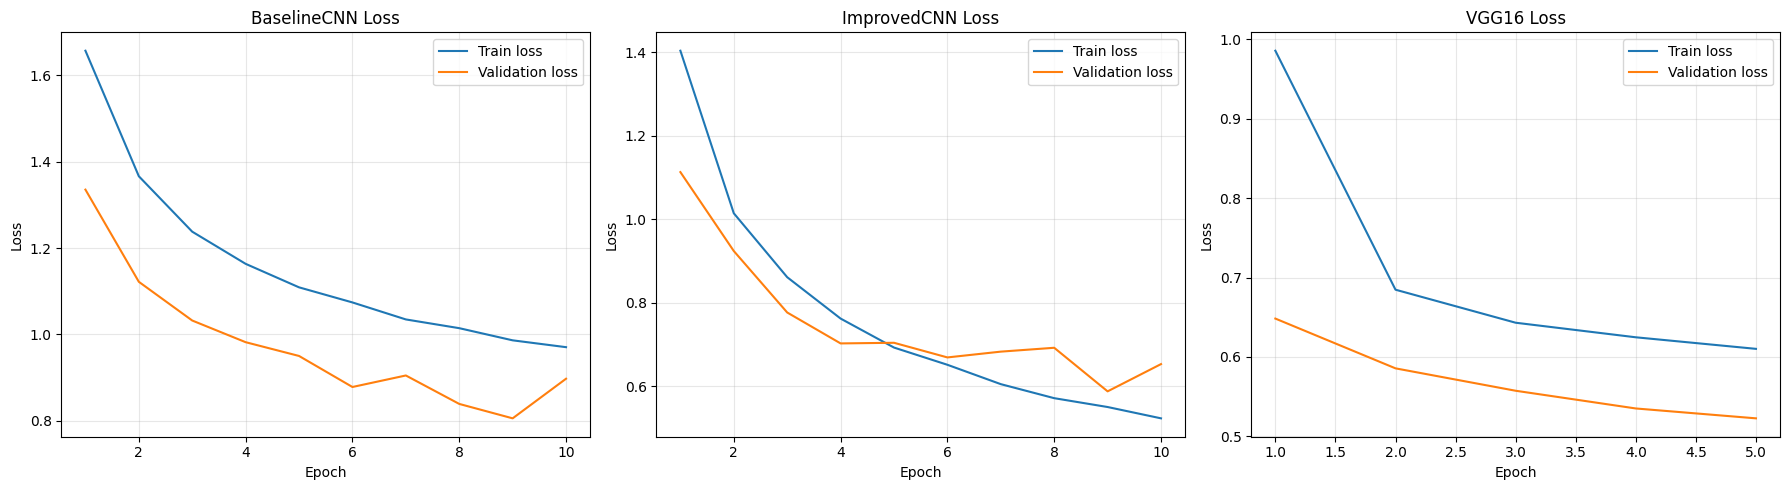

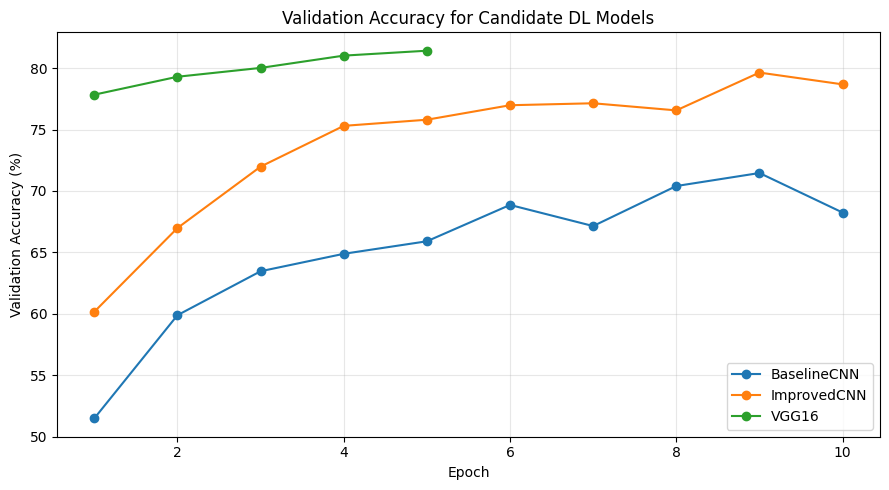

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, result) in zip(axes, results.items()):
    history = result["history"]
    epochs = range(1, len(history["train_loss"]) + 1)

    ax.plot(epochs, history["train_loss"], label="Train loss")
    ax.plot(epochs, history["val_loss"], label="Validation loss")
    ax.set_title(f"{name} Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for name, result in results.items():
    history = result["history"]
    epochs = range(1, len(history["val_acc"]) + 1)
    ax.plot(epochs, [acc * 100 for acc in history["val_acc"]], marker="o", label=name)

ax.set_title("Validation Accuracy for Candidate DL Models")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation Accuracy (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 2.9 Validation Confusion Matrices

The validation confusion matrices show which CIFAR-10 classes each candidate model predicts well or struggles with before the official test set is used. These matrices support the model-selection decision and help identify class-level performance patterns.


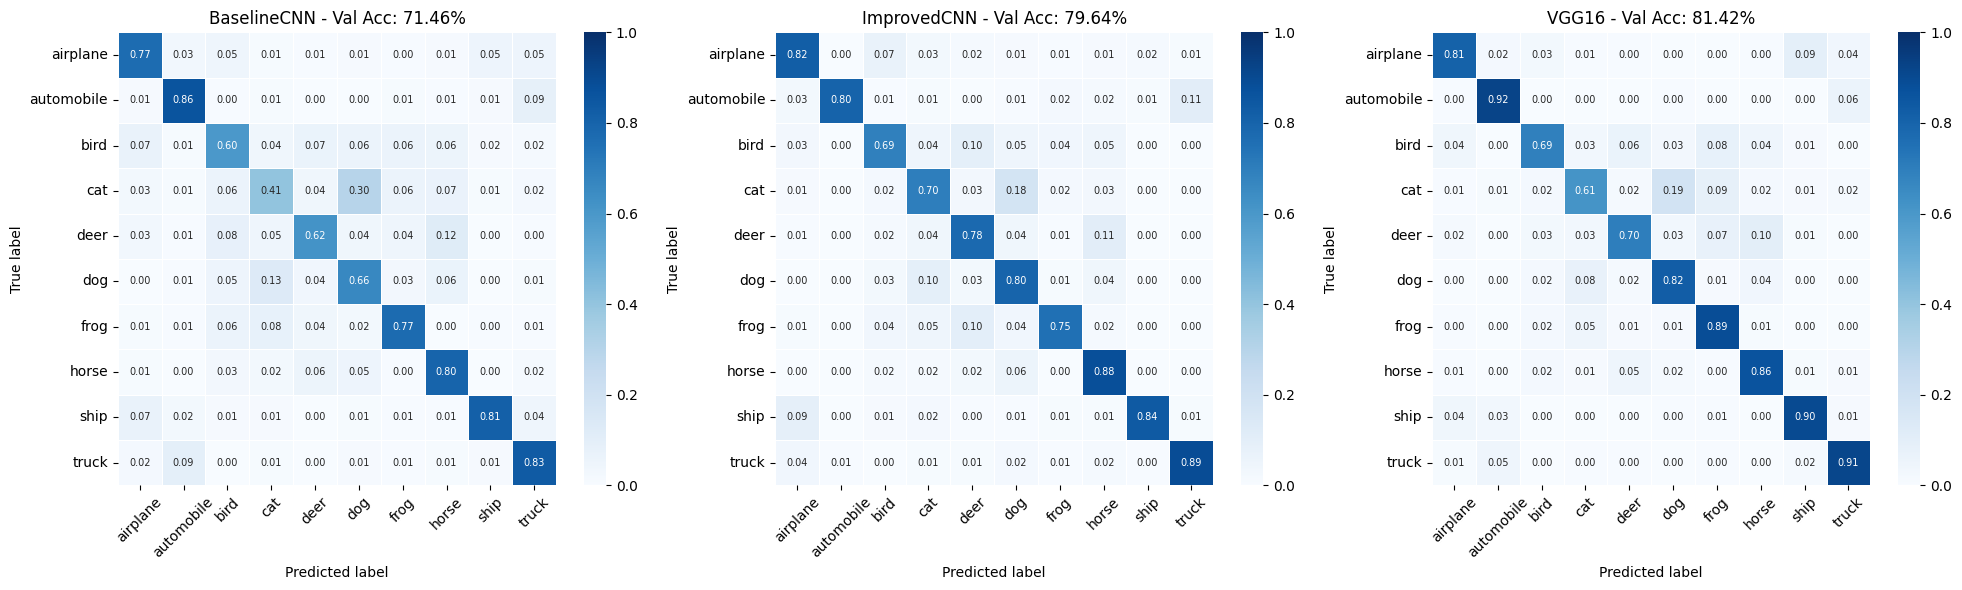

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, result) in zip(axes, results.items()):
    model = result["model"]
    loader = dl_validation_loaders[name]
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            outputs = model(images)
            predictions = outputs.argmax(dim=1).cpu().numpy()
            all_predictions.extend(predictions)
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_predictions)
    cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_normalized,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5,
        vmin=0,
        vmax=1,
        annot_kws={"size": 7},
    )
    ax.set_title(f"{name} - Val Acc: {result['best_val_acc'] * 100:.2f}%")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


### 2.10 Save Training History

The training histories, validation scores, and checkpoint paths are saved so the selected model can be loaded again for final evaluation on the official CIFAR-10 test set.


In [ ]:
history_export = {}
for name, result in results.items():
    history_export[name] = {
        "history": result["history"],
        "best_val_acc": result["best_val_acc"],
        "best_epoch": result["best_epoch"],
        "params_M": result["params_M"],
        "train_sec": result["train_sec"],
        "checkpoint": result["checkpoint"],
    }

history_export["selected_model"] = {
    "name": best_dl_model_name,
    "checkpoint": best_dl_checkpoint_path,
}

with open("dl_training_histories.pkl", "wb") as file:
    pickle.dump(history_export, file)

print("Saved training history: dl_training_histories.pkl")
print("Selected model for final evaluation:", best_dl_model_name)
print("Selected checkpoint:", best_dl_checkpoint_path)


Saved training history: dl_training_histories.pkl
Selected model for final evaluation: VGG16
Selected checkpoint: best_vgg16.pth


## 3. Deep Learning Evaluation and Final DL vs ML Comparison
